# Can GLP-1 Drugs Solve the Obesity Epidemic? An Exploratory Data Analysis

## Project Overview
This project explores the global obesity epidemic and the rapid rise of GLP-1 receptor agonist drugs (Wegovy, Mounjaro, Ozempic) as a treatment. We combine multiple data sources to tell a data-driven story:

1. **How bad is the obesity problem globally?** — WHO global obesity trends
2. **What drives obesity?** — Analysis of individual risk factors
3. **Enter GLP-1 drugs — how fast are they growing?** — Prescription & search trends
4. **How effective are they?** — Published clinical data
5. **Conclusions & recommendations**

---

## Setup & Imports

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Load all datasets
DATA_PATH = 'data/'

obesity_global = pd.read_csv(DATA_PATH + 'obesity_global.csv')
obesity_risk = pd.read_csv(DATA_PATH + 'obesity_level.csv')
google_trends = pd.read_csv(DATA_PATH + 'google_trends_glp1.csv')
glp1_effectiveness = pd.read_csv(DATA_PATH + 'glp1_effectiveness.csv')
glp1_prescriptions = pd.read_csv(DATA_PATH + 'glp1_prescriptions.csv')

print('All libraries loaded and datasets ready!')

All libraries loaded and datasets ready!


---
## 1. Data Exploration
Let's first explore each dataset to understand its structure, size, and quality.

### 1.1 WHO Global Obesity Data
**Source**: WHO Global Health Observatory via [Our World in Data](https://ourworldindata.org/grapher/share-of-adults-defined-as-obese)

In [28]:
# Explore the WHO obesity dataset
print('Shape:', obesity_global.shape)
print('\nColumn names:')
print(obesity_global.columns.tolist())
print('\nFirst 5 rows:')
obesity_global.head()

Shape: (9270, 4)

Column names:
['Entity', 'Code', 'Year', 'Obesity among adults, BMI >= 30 kg/m2 (crude estimate) (%) - Sex: both sexes - Age group: 18+  years of age']

First 5 rows:


,Entity,Code,Year,"Obesity among adults, BMI >= 30 kg/m2 (crude estimate) (%) - Sex: both sexes - Age group: 18+ years of age"
0,Afghanistan,AFG,1980,0.834268
1,Afghanistan,AFG,1981,0.893601
2,Afghanistan,AFG,1982,0.958518
3,Afghanistan,AFG,1983,1.029450
4,Afghanistan,AFG,1984,1.106488


In [29]:
# Rename the long column name for easier use
obesity_global.columns = ['Entity', 'Code', 'Year', 'Obesity_Pct']

# Basic stats
print('Year range:', obesity_global['Year'].min(), '-', obesity_global['Year'].max())
print('Number of countries:', obesity_global['Entity'].nunique())
print('\nMissing values:')
print(obesity_global.isnull().sum())
print('\nObesity % stats:')
obesity_global['Obesity_Pct'].describe()

Year range: 1980 - 2024
Number of countries: 206

Missing values:
Entity         0
Code           0
Year           0
Obesity_Pct    0
dtype: int64

Obesity % stats:


count    9270.000000
mean       15.838194
std        13.223721
min         0.124788
25%         5.891188
50%        13.292583
75%        22.290522
max        75.812290
Name: Obesity_Pct, dtype: float64

In [30]:
# Explore the obesity risk factor dataset
print('Shape:', obesity_risk.shape)
print('\nColumn names:')
print(obesity_risk.columns.tolist())
print('\nFirst 5 rows:')
obesity_risk.head()

Shape: (20758, 18)

Column names:
['id', 'Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', '0be1dad']

First 5 rows:


,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,0be1dad
0,0,Male,24.443011,1.699998,81.669950,1,1,2.000000,2.983297,Sometimes,0,2.763573,0,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,1,1,2.000000,3.000000,Frequently,0,2.000000,0,1.000000,1.000000,0,Automobile,0rmal_Weight
2,2,Female,18.000000,1.711460,50.165754,1,1,1.880534,1.411685,Sometimes,0,1.910378,0,0.866045,1.673584,0,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,1,1,3.000000,3.000000,Sometimes,0,1.674061,0,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,1,1,2.679664,1.971472,Sometimes,0,1.979848,0,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


In [31]:
# Check data types and missing values
print('Data types:\n')
print(obesity_risk.dtypes)
print('\nMissing values:')
print(obesity_risk.isnull().sum())
print('\nObesity level distribution:')
obesity_risk['0be1dad'].value_counts()

Data types:

id                                  int64
Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight      int64
FAVC                                int64
FCVC                              float64
NCP                               float64
CAEC                               object
SMOKE                               int64
CH2O                              float64
SCC                                 int64
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                             object
0be1dad                            object
dtype: object

Missing values:
id                                0
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_

0be1dad
Obesity_Type_III       4046
Obesity_Type_II        3248
0rmal_Weight           3082
Obesity_Type_I         2910
Insufficient_Weight    2523
Overweight_Level_II    2522
Overweight_Level_I     2427
Name: count, dtype: int64

### 1.2 Google Trends & GLP-1 Drug Data

In [32]:
# Explore Google Trends data
print('Shape:', google_trends.shape)
print('\nFirst 5 rows:')
print(google_trends.head())
print('\nLast 5 rows:')
google_trends.tail()

Shape: (78, 4)

First 5 rows:
     Month  Ozempic  Wegovy  Mounjaro
0  2019-01        2       0         0
1  2019-02        2       0         0
2  2019-03        2       0         0
3  2019-04        2       0         0
4  2019-05        2       0         0

Last 5 rows:


,Month,Ozempic,Wegovy,Mounjaro
73,2025-02,48,50,100
74,2025-03,46,50,98
75,2025-04,45,52,95
76,2025-05,44,53,92
77,2025-06,42,55,90


In [33]:
# Explore prescription trends
print('GLP-1 Prescription Trends:\n')
print(glp1_prescriptions)
print('\n\nGLP-1 Drug Effectiveness (Clinical Trials):\n')
print(glp1_effectiveness[['Drug', 'Generic_Name', 'Avg_Weight_Loss_Percent', 'Year_Approved']])

GLP-1 Prescription Trends:

   Year  Total_GLP1_Prescriptions_Millions  Ozempic_Share  Wegovy_Share  \
0  2018                                4.2           0.15          0.00   
1  2019                                5.8           0.22          0.00   
2  2020                                6.9           0.28          0.00   
3  2021                                9.2           0.35          0.05   
4  2022                               15.8           0.38          0.08   
5  2023                               29.4           0.32          0.12   
6  2024                               45.0           0.25          0.15   

   Mounjaro_Share  Other_Share  Total_Spending_Billion_USD  
0            0.00         0.85                         2.6  
1            0.00         0.78                         3.8  
2            0.00         0.72                         4.5  
3            0.00         0.60                         6.3  
4            0.10         0.44                        13.5  
5    

### 1.3 Dataset Summary

In [34]:
# Summary of all datasets
print('=' * 60)
print('DATASET SUMMARY')
print('=' * 60)
print(f'\n1. WHO Global Obesity:  {obesity_global.shape[0]:,} rows, {obesity_global.shape[1]} cols')
print(f'   Years: {obesity_global["Year"].min()} - {obesity_global["Year"].max()}')
print(f'   Countries: {obesity_global["Entity"].nunique()}')
print(f'\n2. Obesity Risk Factors: {obesity_risk.shape[0]:,} rows, {obesity_risk.shape[1]} cols')
print(f'   Features: {obesity_risk.columns.tolist()}')
print(f'\n3. Google Trends:       {google_trends.shape[0]} rows, {google_trends.shape[1]} cols')
print(f'   Period: {google_trends["Month"].iloc[0]} to {google_trends["Month"].iloc[-1]}')
print(f'\n4. GLP-1 Effectiveness: {glp1_effectiveness.shape[0]} drugs compared')
print(f'\n5. GLP-1 Prescriptions: {glp1_prescriptions.shape[0]} years of data')
print(f'   Period: {glp1_prescriptions["Year"].min()} - {glp1_prescriptions["Year"].max()}')
print('\n' + '=' * 60)
print('All datasets loaded and ready for analysis!')
print('=' * 60)

DATASET SUMMARY

1. WHO Global Obesity:  9,270 rows, 4 cols
   Years: 1980 - 2024
   Countries: 206

2. Obesity Risk Factors: 20,758 rows, 18 cols
   Features: ['id', 'Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', '0be1dad']

3. Google Trends:       78 rows, 4 cols
   Period: 2019-01 to 2025-06

4. GLP-1 Effectiveness: 6 drugs compared

5. GLP-1 Prescriptions: 7 years of data
   Period: 2018 - 2024

All datasets loaded and ready for analysis!


---
## 2. Data Cleaning

### 2.1 WHO Global Obesity Data
The dataset contains both individual countries and regional groupings (like "World", "Europe"). We need to separate them for accurate analysis.

In [35]:
# Separate regions from countries
# Regions have special codes like "WHO_AFR" or are groupings like "World"
regions = ['World', 'Africa (WHO)', 'Americas (WHO)', 'Eastern Mediterranean (WHO)',
           'Europe (WHO)', 'South-East Asia (WHO)', 'Western Pacific (WHO)']

# Split into two dataframes
obesity_regions = obesity_global[obesity_global['Entity'].isin(regions)].copy()
obesity_countries = obesity_global[~obesity_global['Entity'].isin(regions)].copy()

print(f'Original dataset: {len(obesity_global)} rows')
print(f'Countries only:   {len(obesity_countries)} rows ({obesity_countries["Entity"].nunique()} countries)')
print(f'Regions only:     {len(obesity_regions)} rows ({obesity_regions["Entity"].nunique()} regions)')
print(f'\nRegions found: {obesity_regions["Entity"].unique().tolist()}')

Original dataset: 9270 rows
Countries only:   8955 rows (199 countries)
Regions only:     315 rows (7 regions)

Regions found: ['Africa (WHO)', 'Americas (WHO)', 'Eastern Mediterranean (WHO)', 'Europe (WHO)', 'South-East Asia (WHO)', 'Western Pacific (WHO)', 'World']


### 2.2 Obesity Risk Factor Data
Renaming coded column names to readable ones, fixing typos, and dropping unnecessary columns.

In [36]:
# Rename columns to readable names
obesity_risk = obesity_risk.rename(columns={
    '0be1dad': 'Obesity_Level',
    'FAVC': 'Freq_High_Cal_Food',      # Frequent consumption of high caloric food
    'FCVC': 'Freq_Vegetables',          # Frequency of vegetable consumption
    'NCP': 'Num_Meals',                 # Number of main meals
    'CAEC': 'Eating_Between_Meals',     # Consumption of food between meals
    'CH2O': 'Water_Daily',              # Daily water consumption
    'SCC': 'Calorie_Monitoring',        # Calories consumption monitoring
    'FAF': 'Physical_Activity_Freq',    # Physical activity frequency
    'TUE': 'Technology_Use',            # Time using technology devices
    'CALC': 'Alcohol_Consumption',      # Consumption of alcohol
    'MTRANS': 'Transportation'          # Transportation used
})

# Fix the typo: '0rmal_Weight' -> 'Normal_Weight'
obesity_risk['Obesity_Level'] = obesity_risk['Obesity_Level'].replace('0rmal_Weight', 'Normal_Weight')

# Drop the 'id' column (not useful for analysis)
obesity_risk = obesity_risk.drop(columns=['id'])

print('Cleaned columns:')
print(obesity_risk.columns.tolist())
print('\nObesity Level distribution (after fix):')
print(obesity_risk['Obesity_Level'].value_counts())

Cleaned columns:
['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'Freq_High_Cal_Food', 'Freq_Vegetables', 'Num_Meals', 'Eating_Between_Meals', 'SMOKE', 'Water_Daily', 'Calorie_Monitoring', 'Physical_Activity_Freq', 'Technology_Use', 'Alcohol_Consumption', 'Transportation', 'Obesity_Level']

Obesity Level distribution (after fix):
Obesity_Level
Obesity_Type_III       4046
Obesity_Type_II        3248
Normal_Weight          3082
Obesity_Type_I         2910
Insufficient_Weight    2523
Overweight_Level_II    2522
Overweight_Level_I     2427
Name: count, dtype: int64


---
## 3. Global Obesity Trends

### Chart 1: Global Obesity Rate Over Time (1980–2024)
How has the world's obesity rate changed in the last 44 years?

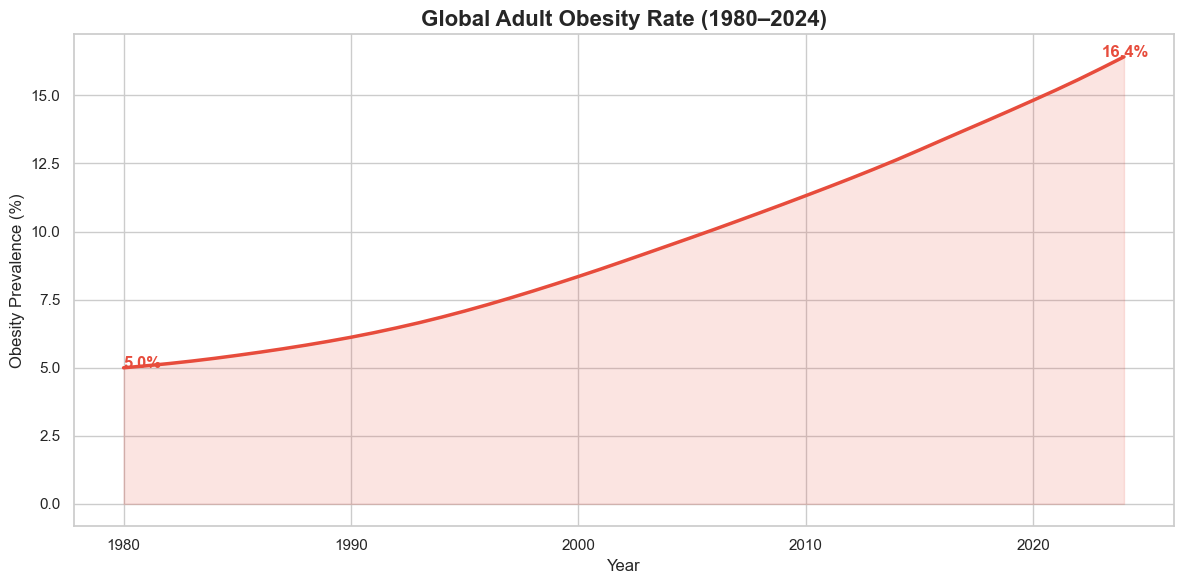

Obesity rate increased from 5.0% to 16.4% — a 3.3x increase!


In [37]:
# Chart 1: Global obesity rate over time
world_data = obesity_regions[obesity_regions['Entity'] == 'World']

plt.figure(figsize=(12, 6))
plt.plot(world_data['Year'], world_data['Obesity_Pct'], linewidth=2.5, color='#e74c3c')
plt.fill_between(world_data['Year'], world_data['Obesity_Pct'], alpha=0.15, color='#e74c3c')

plt.title('Global Adult Obesity Rate (1980–2024)', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Obesity Prevalence (%)')
plt.annotate(f'{world_data["Obesity_Pct"].iloc[0]:.1f}%',
             xy=(1980, world_data['Obesity_Pct'].iloc[0]),
             fontsize=12, fontweight='bold', color='#e74c3c')
plt.annotate(f'{world_data["Obesity_Pct"].iloc[-1]:.1f}%',
             xy=(2023, world_data['Obesity_Pct'].iloc[-1]),
             fontsize=12, fontweight='bold', color='#e74c3c')

plt.tight_layout()
plt.savefig('images/chart1_global_trend.png', dpi=150)
plt.show()
print(f'Obesity rate increased from {world_data["Obesity_Pct"].iloc[0]:.1f}% to {world_data["Obesity_Pct"].iloc[-1]:.1f}% — a {world_data["Obesity_Pct"].iloc[-1] / world_data["Obesity_Pct"].iloc[0]:.1f}x increase!')

### Chart 2: Obesity Rates in Key GLP-1 Drug Markets
How do the countries where Wegovy and Mounjaro are sold compare?

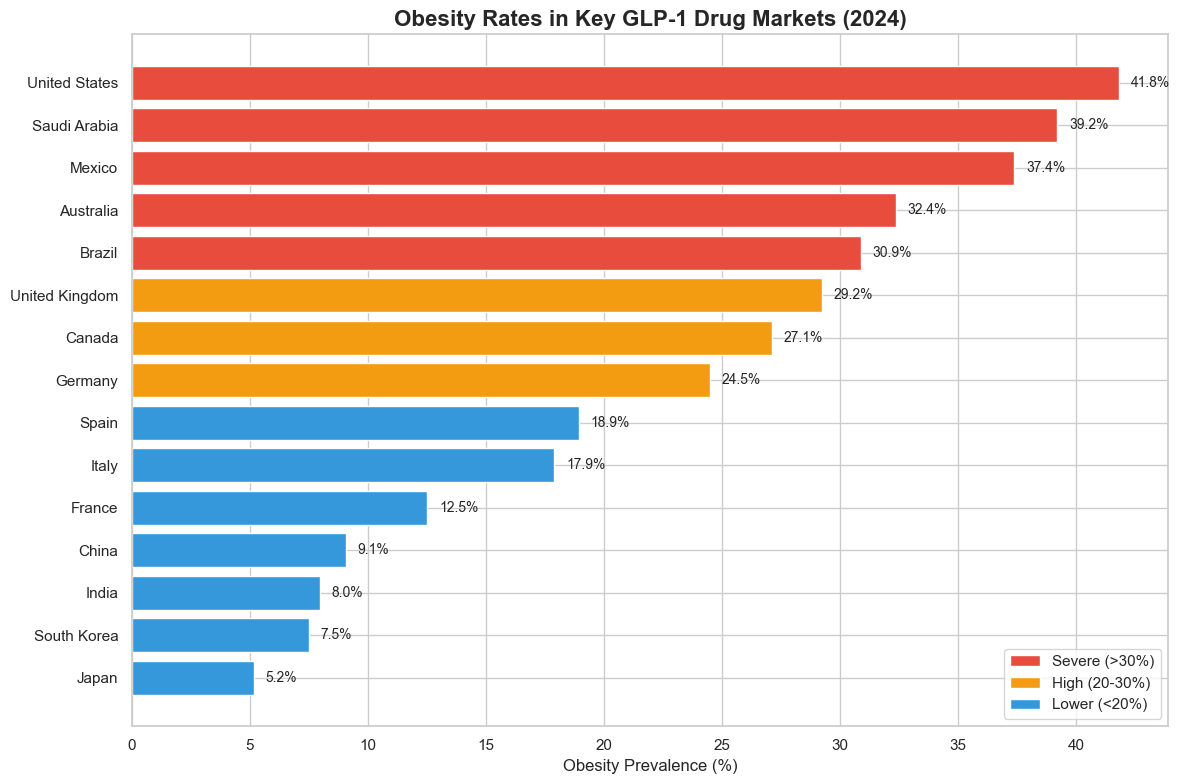


The US has the highest obesity rate (41.8%) among major GLP-1 markets.
This helps explain why GLP-1 drug demand started — and remains strongest — in the US.


In [38]:
# Chart 2: Obesity rates in countries where GLP-1 drugs are sold
glp1_market_countries = ['United States', 'United Kingdom', 'Germany', 'France', 'Japan',
                         'Canada', 'Australia', 'Brazil', 'Mexico', 'South Korea',
                         'Italy', 'Spain', 'India', 'China', 'Saudi Arabia']

latest_year = obesity_countries['Year'].max()
latest_data = obesity_countries[
    (obesity_countries['Year'] == latest_year) & 
    (obesity_countries['Entity'].isin(glp1_market_countries))
].sort_values('Obesity_Pct', ascending=True)

plt.figure(figsize=(12, 8))
colors = ['#e74c3c' if val > 30 else '#f39c12' if val > 20 else '#3498db' 
          for val in latest_data['Obesity_Pct']]
bars = plt.barh(latest_data['Entity'], latest_data['Obesity_Pct'], color=colors, edgecolor='white')

plt.xlabel('Obesity Prevalence (%)')
plt.title(f'Obesity Rates in Key GLP-1 Drug Markets ({latest_year})', fontsize=16, fontweight='bold')

# Add value labels
for bar, val in zip(bars, latest_data['Obesity_Pct']):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=10)

# Add a legend for the colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Severe (>30%)'),
                   Patch(facecolor='#f39c12', label='High (20-30%)'),
                   Patch(facecolor='#3498db', label='Lower (<20%)')]
plt.legend(handles=legend_elements, loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig('images/chart2_glp1_markets.png', dpi=150)
plt.show()

print(f'\nThe US has the highest obesity rate ({latest_data["Obesity_Pct"].max():.1f}%) among major GLP-1 markets.')
print(f'This helps explain why GLP-1 drug demand started — and remains strongest — in the US.')

### Chart 3: Obesity Trends by WHO Region
How do different parts of the world compare?

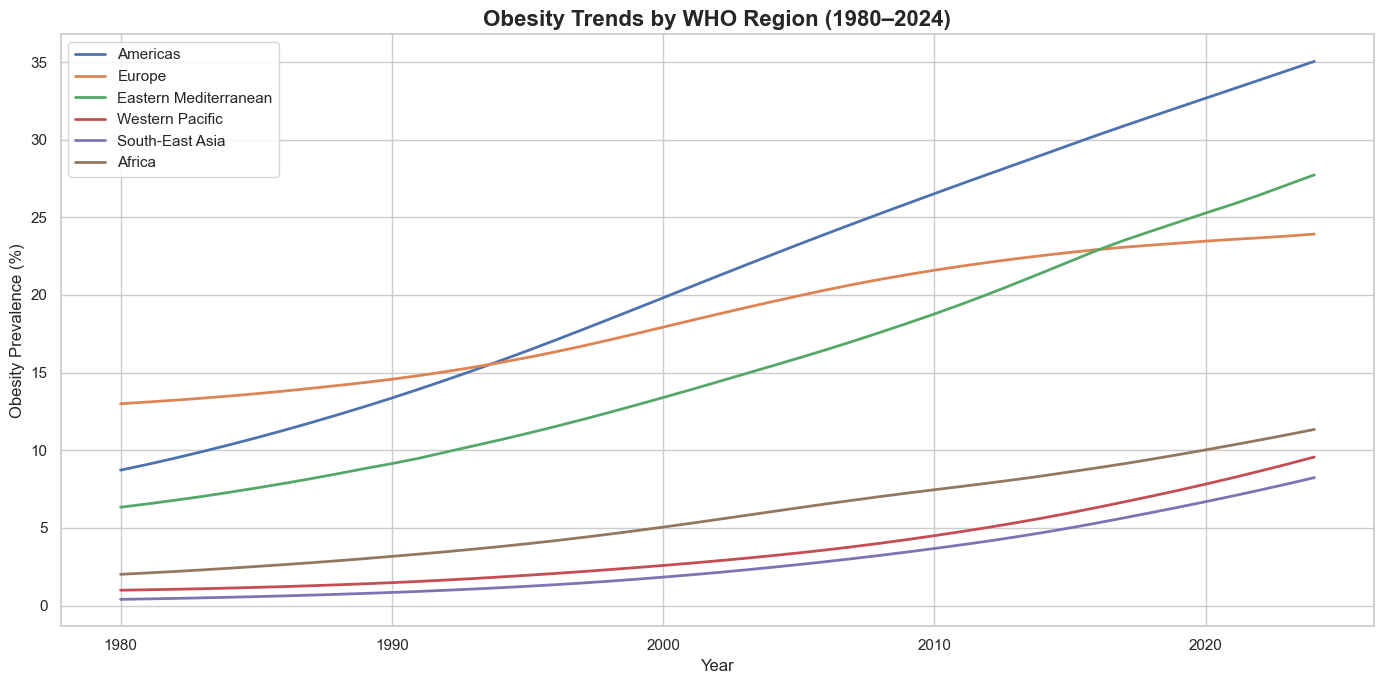

In [39]:
# Chart 3: Obesity trends by WHO region
plt.figure(figsize=(14, 7))

# Shorten region names for the legend
region_labels = {
    'Americas (WHO)': 'Americas',
    'Europe (WHO)': 'Europe',
    'Eastern Mediterranean (WHO)': 'Eastern Mediterranean',
    'Western Pacific (WHO)': 'Western Pacific',
    'South-East Asia (WHO)': 'South-East Asia',
    'Africa (WHO)': 'Africa'
}

for region in region_labels:
    data = obesity_regions[obesity_regions['Entity'] == region]
    plt.plot(data['Year'], data['Obesity_Pct'], linewidth=2, label=region_labels[region])

plt.title('Obesity Trends by WHO Region (1980–2024)', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Obesity Prevalence (%)')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('images/chart3_regions.png', dpi=150)
plt.show()

**Key findings:**
- Global obesity has more than tripled since 1980
- Every WHO region shows an upward trend — this is a global epidemic
- The Americas and Europe have the highest rates
- The US leads GLP-1 drug markets with 41.8% obesity prevalence

---
## 4. What Drives Obesity? Risk Factor Analysis

Understanding the individual-level factors that contribute to obesity risk.

In [40]:
# Quick overview of numerical features by obesity level
# Order the obesity levels from lightest to heaviest
level_order = ['Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I', 
               'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']

print('Average values by Obesity Level:\n')
summary = obesity_risk.groupby('Obesity_Level')[
    ['Age', 'Weight', 'Physical_Activity_Freq', 'Freq_Vegetables', 'Water_Daily', 'Technology_Use']
].mean().reindex(level_order).round(2)
summary

Average values by Obesity Level:



,Age,Weight,Physical_Activity_Freq,Freq_Vegetables,Water_Daily,Technology_Use
Obesity_Level,,,,,,
Insufficient_Weight,19.34,49.86,1.20,2.48,1.74,0.80
Normal_Weight,20.80,61.53,1.19,2.37,1.81,0.63
Overweight_Level_I,23.05,74.23,1.13,2.26,2.07,0.56
Overweight_Level_II,26.03,82.09,1.06,2.22,2.00,0.70
Obesity_Type_I,25.02,92.37,0.92,2.10,2.13,0.74
Obesity_Type_II,27.71,116.00,1.03,2.43,1.99,0.42
Obesity_Type_III,24.13,117.70,0.55,3.00,2.33,0.55


### Chart 4: Distribution of Obesity Levels
How many people fall into each weight category?

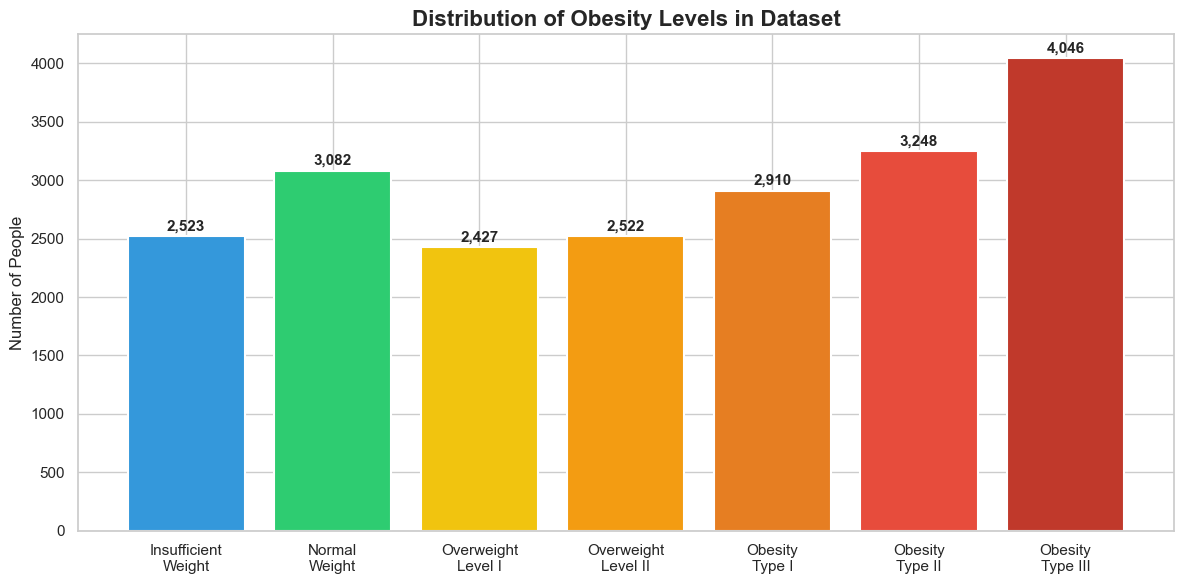

73.0% of people in this dataset are overweight or obese.


In [41]:
# Chart 4: Obesity level distribution
level_order = ['Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I', 
               'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']

level_colors = ['#3498db', '#2ecc71', '#f1c40f', '#f39c12', '#e67e22', '#e74c3c', '#c0392b']

counts = obesity_risk['Obesity_Level'].value_counts().reindex(level_order)

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(counts)), counts.values, color=level_colors, edgecolor='white', linewidth=1.5)

plt.xticks(range(len(counts)), ['Insufficient\nWeight', 'Normal\nWeight', 'Overweight\nLevel I', 
            'Overweight\nLevel II', 'Obesity\nType I', 'Obesity\nType II', 'Obesity\nType III'], fontsize=11)
plt.ylabel('Number of People')
plt.title('Distribution of Obesity Levels in Dataset', fontsize=16, fontweight='bold')

# Add count labels on bars
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{val:,}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('images/chart4_obesity_distribution.png', dpi=150)
plt.show()

# Calculate percentage who are overweight or obese
overweight_obese = obesity_risk[~obesity_risk['Obesity_Level'].isin(['Insufficient_Weight', 'Normal_Weight'])]
pct = len(overweight_obese) / len(obesity_risk) * 100
print(f'{pct:.1f}% of people in this dataset are overweight or obese.')

### Chart 5: Physical Activity vs Obesity Level
Does exercise frequency differ between weight categories?

/var/folders/01/cjv7s5vn3vbgdqc65ztm9v0w0000gn/T/ipykernel_52924/3249798728.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=obesity_risk, x='Obesity_Level', y='Physical_Activity_Freq',


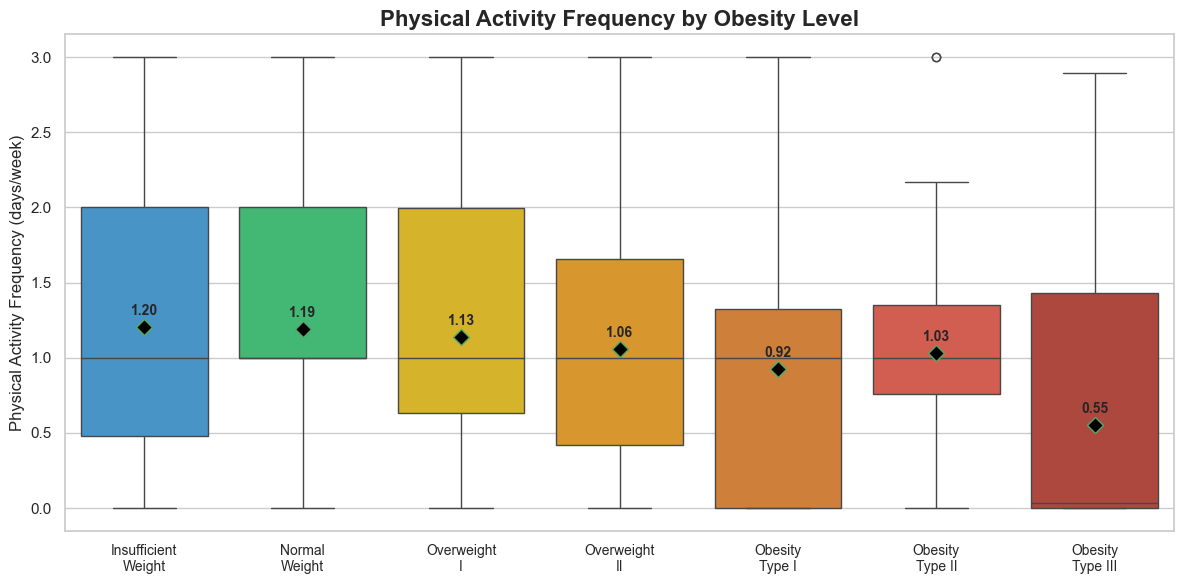

In [42]:
# Chart 5: Physical activity frequency by obesity level
plt.figure(figsize=(12, 6))
sns.boxplot(data=obesity_risk, x='Obesity_Level', y='Physical_Activity_Freq',
            order=level_order, palette=level_colors, showmeans=True,
            meanprops={'marker': 'D', 'markerfacecolor': 'black', 'markersize': 8})
plt.xticks(range(len(level_order)), ['Insufficient\nWeight', 'Normal\nWeight', 'Overweight\nI', 
            'Overweight\nII', 'Obesity\nType I', 'Obesity\nType II', 'Obesity\nType III'], fontsize=10)

# Add mean value labels
means = obesity_risk.groupby('Obesity_Level')['Physical_Activity_Freq'].mean().reindex(level_order)
for i, mean_val in enumerate(means):
    plt.text(i, mean_val + 0.08, f'{mean_val:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.ylabel('Physical Activity Frequency (days/week)')
plt.xlabel('')
plt.title('Physical Activity Frequency by Obesity Level', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('images/chart5_physical_activity.png', dpi=150)
plt.show()

### Chart 6: Family History — The Role of Genetics
How much does having a family history of being overweight affect obesity risk?

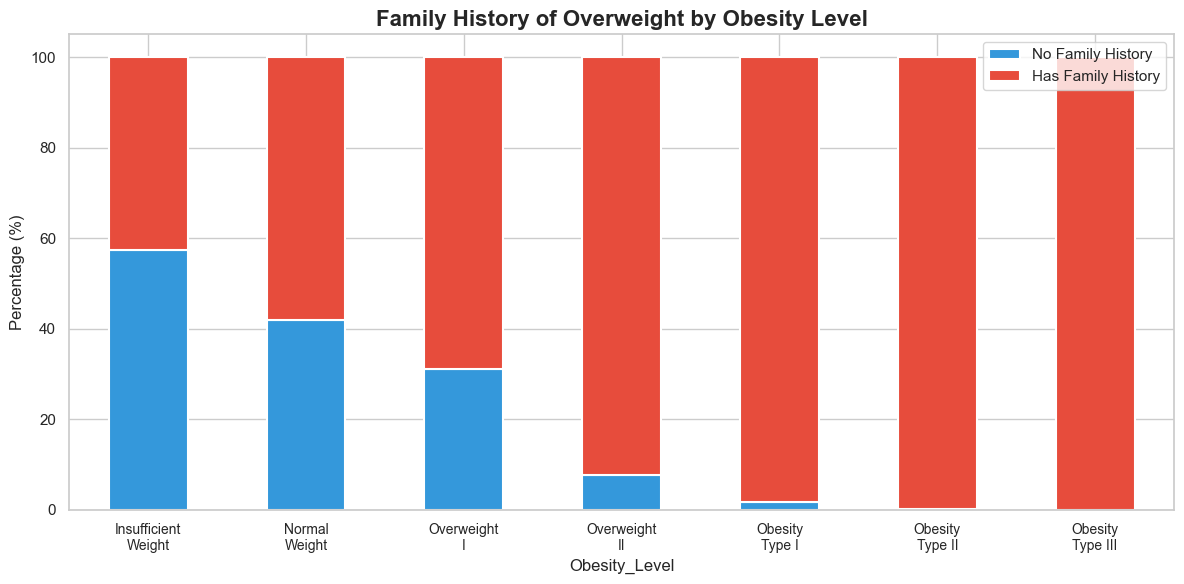

People with obesity: 99.5% have family history of overweight
People with normal weight: 58.1% have family history of overweight


In [43]:
# Chart 6: Family history vs obesity level
family_data = obesity_risk.groupby(['Obesity_Level', 'family_history_with_overweight']).size().unstack()
family_data = family_data.reindex(level_order)
family_pct = family_data.div(family_data.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 6))
family_pct.plot(kind='bar', stacked=True, color=['#3498db', '#e74c3c'], 
                edgecolor='white', linewidth=1.5, ax=plt.gca())
plt.xticks(range(len(level_order)), ['Insufficient\nWeight', 'Normal\nWeight', 'Overweight\nI', 
            'Overweight\nII', 'Obesity\nType I', 'Obesity\nType II', 'Obesity\nType III'], 
           rotation=0, fontsize=10)
plt.ylabel('Percentage (%)')
plt.title('Family History of Overweight by Obesity Level', fontsize=16, fontweight='bold')
plt.legend(['No Family History', 'Has Family History'], fontsize=11)
plt.tight_layout()
plt.savefig('images/chart6_family_history.png', dpi=150)
plt.show()

# Calculate the stat
obese_with_family = obesity_risk[obesity_risk['Obesity_Level'].str.contains('Obesity')]['family_history_with_overweight'].mean() * 100
normal_with_family = obesity_risk[obesity_risk['Obesity_Level'] == 'Normal_Weight']['family_history_with_overweight'].mean() * 100
print(f'People with obesity: {obese_with_family:.1f}% have family history of overweight')
print(f'People with normal weight: {normal_with_family:.1f}% have family history of overweight')

### Chart 7: Eating Habits vs Obesity Level
How do high calorie food consumption and vegetable intake relate to obesity?

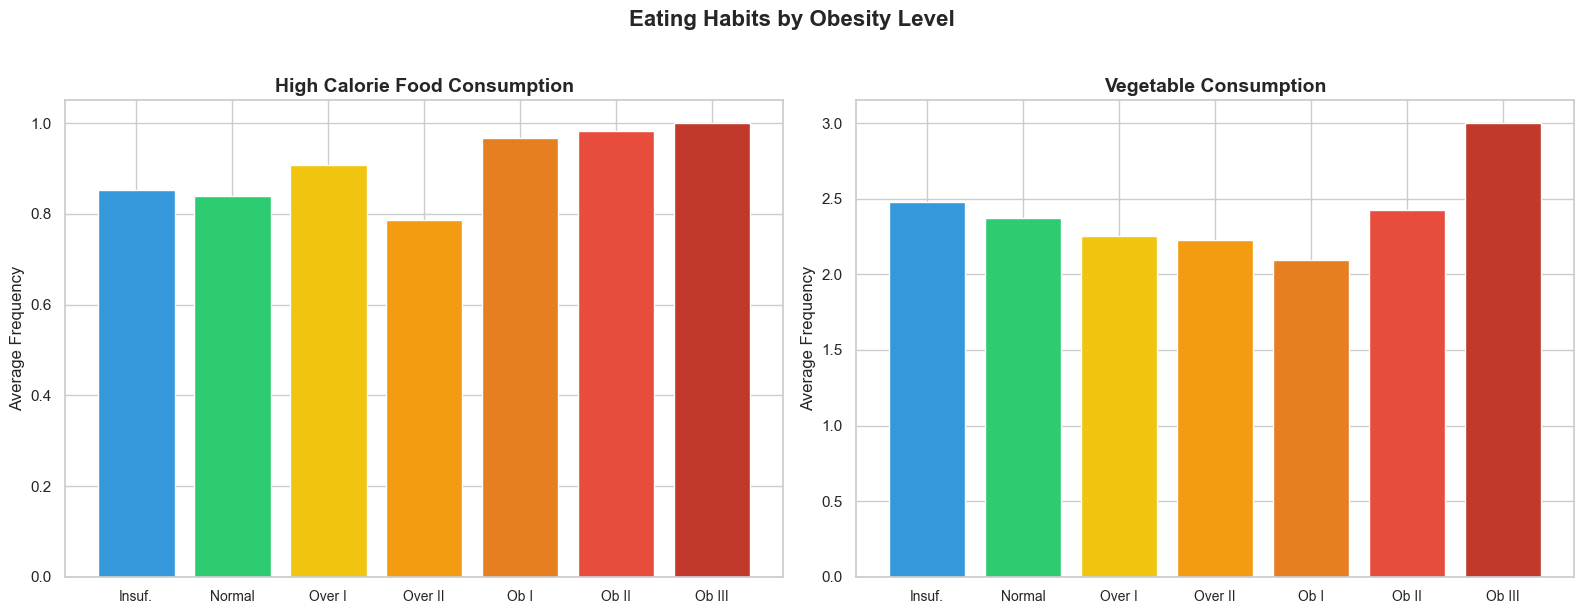

In [44]:
# Chart 7: Eating habits comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# High calorie food consumption by obesity level
high_cal = obesity_risk.groupby('Obesity_Level')['Freq_High_Cal_Food'].mean().reindex(level_order)
axes[0].bar(range(len(high_cal)), high_cal.values, color=level_colors, edgecolor='white')
axes[0].set_xticks(range(len(level_order)))
axes[0].set_xticklabels(['Insuf.', 'Normal', 'Over I', 'Over II', 'Ob I', 'Ob II', 'Ob III'], fontsize=10)
axes[0].set_ylabel('Average Frequency')
axes[0].set_title('High Calorie Food Consumption', fontsize=14, fontweight='bold')

# Vegetable consumption by obesity level
veg = obesity_risk.groupby('Obesity_Level')['Freq_Vegetables'].mean().reindex(level_order)
axes[1].bar(range(len(veg)), veg.values, color=level_colors, edgecolor='white')
axes[1].set_xticks(range(len(level_order)))
axes[1].set_xticklabels(['Insuf.', 'Normal', 'Over I', 'Over II', 'Ob I', 'Ob II', 'Ob III'], fontsize=10)
axes[1].set_ylabel('Average Frequency')
axes[1].set_title('Vegetable Consumption', fontsize=14, fontweight='bold')

plt.suptitle('Eating Habits by Obesity Level', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/chart7_eating_habits.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 8: Correlation Heatmap — Which Factors Matter Most?

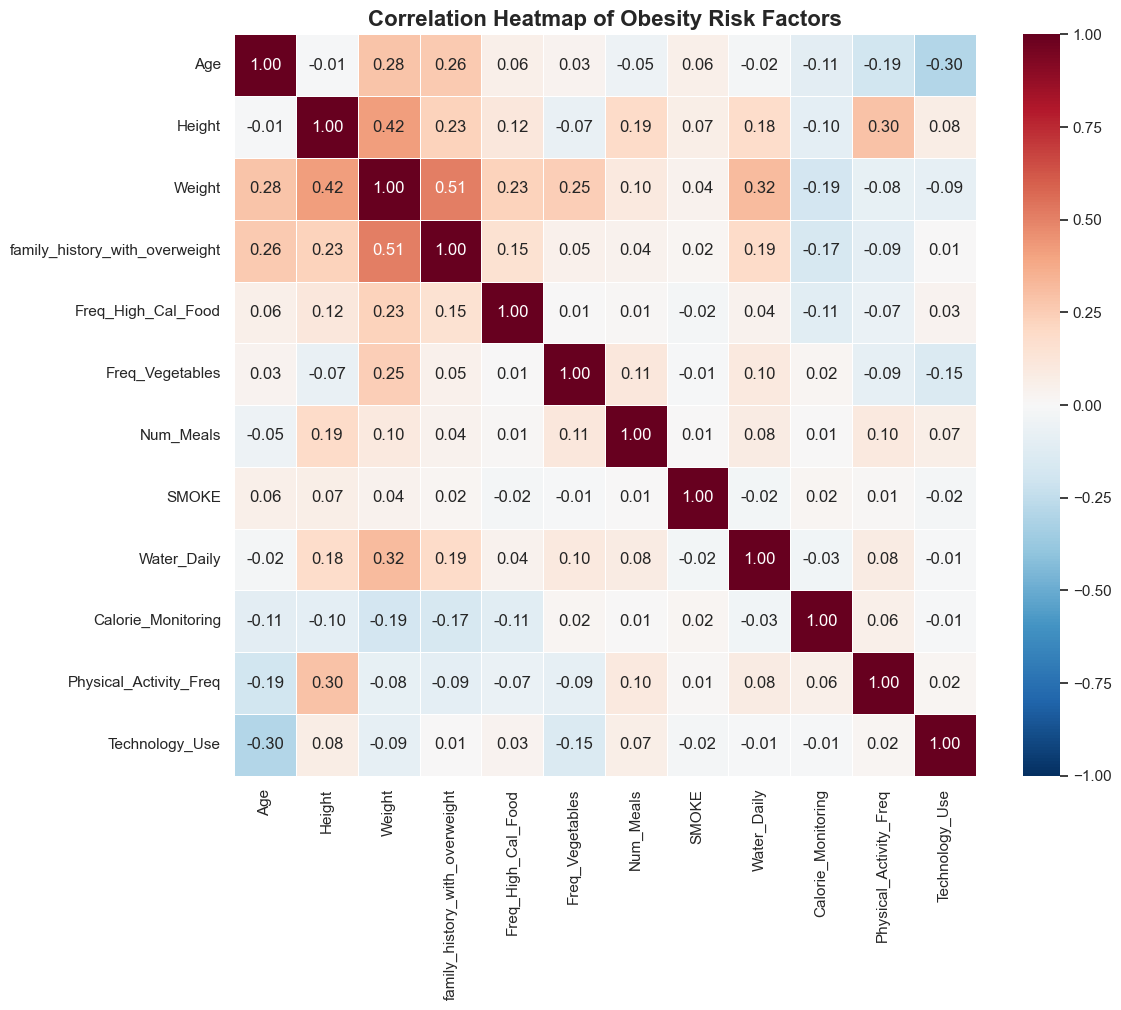


Correlations with Weight (strongest to weakest):
  family_history_with_overweight      0.514 (positive)
  Height                              0.417 (positive)
  Water_Daily                         0.318 (positive)
  Age                                 0.283 (positive)
  Freq_Vegetables                     0.246 (positive)
  Freq_High_Cal_Food                  0.229 (positive)
  Calorie_Monitoring                  0.185 (negative)
  Num_Meals                           0.096 (positive)
  Technology_Use                      0.086 (negative)
  Physical_Activity_Freq              0.085 (negative)
  SMOKE                               0.040 (positive)


In [45]:
# Chart 8: Correlation heatmap of numerical features
numerical_cols = ['Age', 'Height', 'Weight', 'family_history_with_overweight', 
                  'Freq_High_Cal_Food', 'Freq_Vegetables', 'Num_Meals',
                  'SMOKE', 'Water_Daily', 'Calorie_Monitoring',
                  'Physical_Activity_Freq', 'Technology_Use']

corr_matrix = obesity_risk[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Obesity Risk Factors', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('images/chart8_correlation.png', dpi=150)
plt.show()

# Highlight strongest correlations with Weight
print('\nCorrelations with Weight (strongest to weakest):')
weight_corr = corr_matrix['Weight'].drop('Weight').abs().sort_values(ascending=False)
for feature, corr in weight_corr.items():
    direction = 'positive' if corr_matrix.loc[feature, 'Weight'] > 0 else 'negative'
    print(f'  {feature:35s} {corr:.3f} ({direction})')

**Key findings:**
- **Family history** is a major factor — obesity has a strong genetic component
- **Physical activity** is lower in higher obesity categories
- **High calorie food** consumption is higher among those with obesity
- Obesity is **multi-factorial** — no single lifestyle change can fully explain or prevent it
- This supports the argument that medical interventions like GLP-1 drugs are needed, not just lifestyle changes

---
## 5. The Rise of GLP-1 Drugs

### Chart 9: Total GLP-1 Prescriptions Over Time
How fast has GLP-1 drug adoption grown?

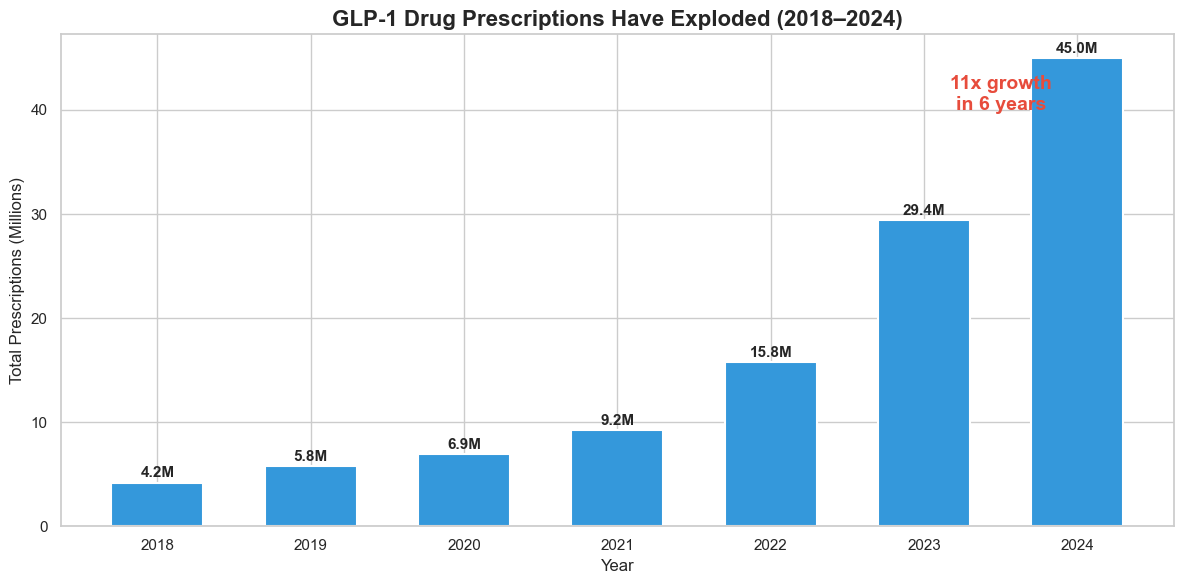

In [46]:
# Chart 9: Total GLP-1 prescriptions over time
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(glp1_prescriptions['Year'], glp1_prescriptions['Total_GLP1_Prescriptions_Millions'],
              color='#3498db', edgecolor='white', linewidth=1.5, width=0.6)

# Add value labels on bars
for bar, val in zip(bars, glp1_prescriptions['Total_GLP1_Prescriptions_Millions']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}M', ha='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Year')
ax.set_ylabel('Total Prescriptions (Millions)')
ax.set_title('GLP-1 Drug Prescriptions Have Exploded (2018–2024)', fontsize=16, fontweight='bold')

# Calculate growth
growth = glp1_prescriptions['Total_GLP1_Prescriptions_Millions'].iloc[-1] / glp1_prescriptions['Total_GLP1_Prescriptions_Millions'].iloc[0]
ax.annotate(f'{growth:.0f}x growth\nin 6 years', xy=(2023.5, 40), fontsize=14,
            fontweight='bold', color='#e74c3c', ha='center')

plt.tight_layout()
plt.savefig('images/chart9_prescriptions.png', dpi=150)
plt.show()

### Chart 10: Public Search Interest Over Time
When did the public start paying attention to GLP-1 drugs?

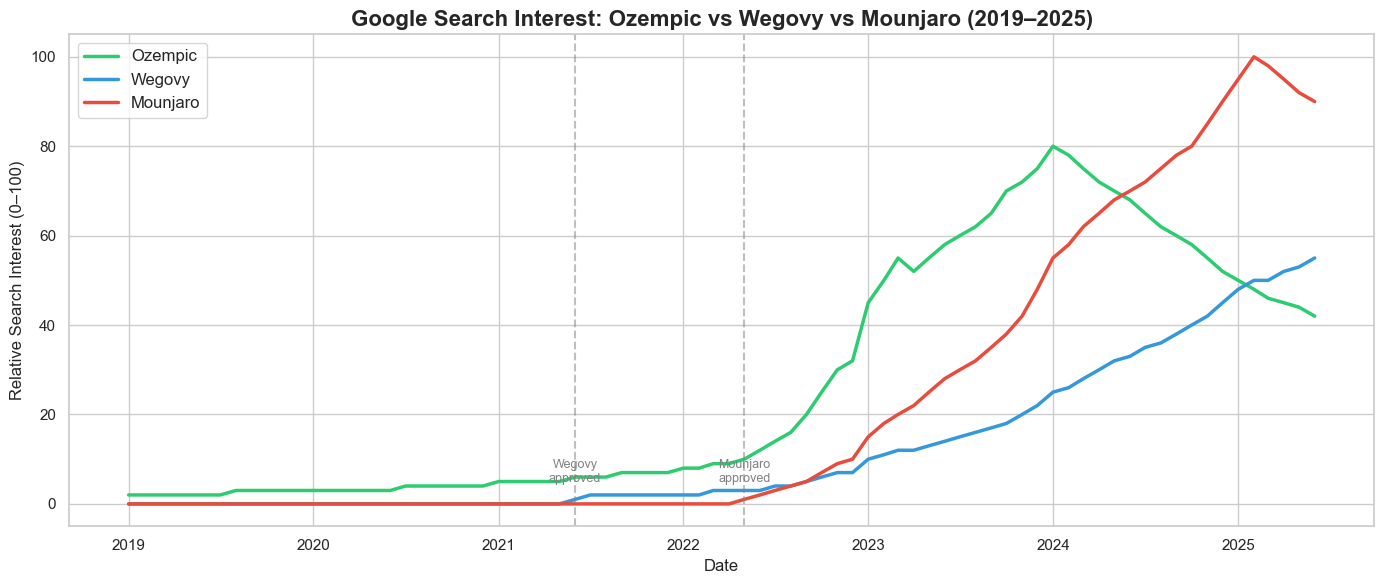

Key observations:
- Ozempic was the first to gain public attention (late 2022), driven by celebrity use
- Mounjaro has overtaken both Ozempic and Wegovy in search interest by 2025
- The crossover point shows a shift in public preference toward newer, more effective drugs


In [47]:
# Chart 10: Google Trends — search interest over time
google_trends['Date'] = pd.to_datetime(google_trends['Month'])

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(google_trends['Date'], google_trends['Ozempic'], linewidth=2.5, label='Ozempic', color='#2ecc71')
ax.plot(google_trends['Date'], google_trends['Wegovy'], linewidth=2.5, label='Wegovy', color='#3498db')
ax.plot(google_trends['Date'], google_trends['Mounjaro'], linewidth=2.5, label='Mounjaro', color='#e74c3c')

ax.set_xlabel('Date')
ax.set_ylabel('Relative Search Interest (0–100)')
ax.set_title('Google Search Interest: Ozempic vs Wegovy vs Mounjaro (2019–2025)', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)

# Add key event annotations
ax.axvline(x=pd.Timestamp('2021-06-01'), color='gray', linestyle='--', alpha=0.5)
ax.annotate('Wegovy\napproved', xy=(pd.Timestamp('2021-06-01'), 5), fontsize=9, color='gray', ha='center')

ax.axvline(x=pd.Timestamp('2022-05-01'), color='gray', linestyle='--', alpha=0.5)
ax.annotate('Mounjaro\napproved', xy=(pd.Timestamp('2022-05-01'), 5), fontsize=9, color='gray', ha='center')

plt.tight_layout()
plt.savefig('images/chart10_google_trends.png', dpi=150)
plt.show()

print('Key observations:')
print('- Ozempic was the first to gain public attention (late 2022), driven by celebrity use')
print('- Mounjaro has overtaken both Ozempic and Wegovy in search interest by 2025')
print('- The crossover point shows a shift in public preference toward newer, more effective drugs')

### Chart 11: Total Spending on GLP-1 Drugs

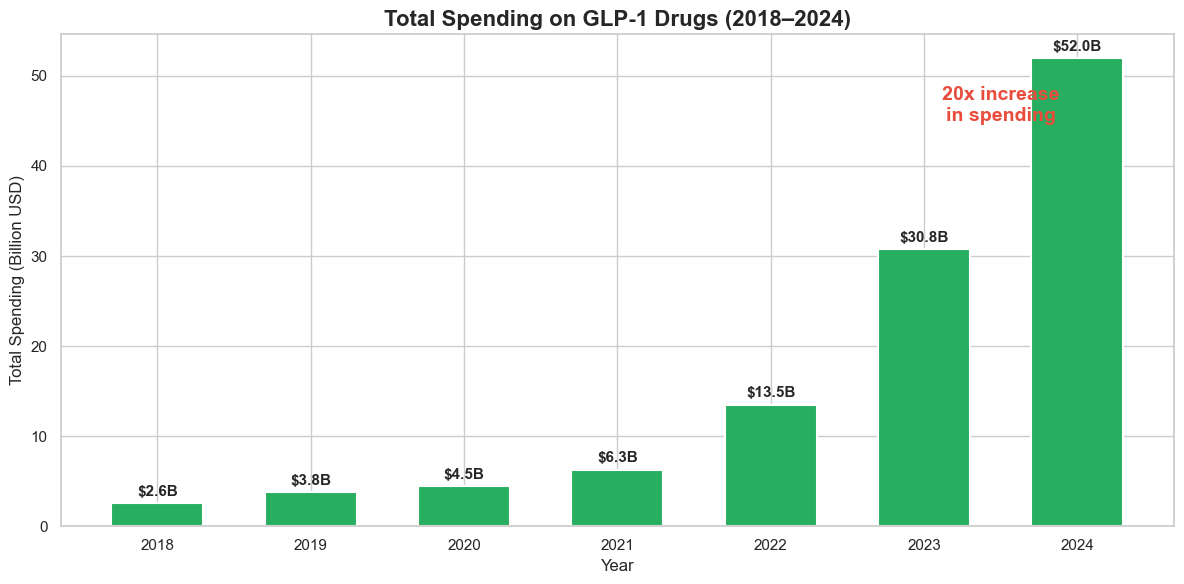

In [48]:
# Chart 11: Total spending on GLP-1 drugs
fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(glp1_prescriptions['Year'], glp1_prescriptions['Total_Spending_Billion_USD'],
       color='#27ae60', edgecolor='white', linewidth=1.5, width=0.6)

# Add value labels
for i, (year, val) in enumerate(zip(glp1_prescriptions['Year'], glp1_prescriptions['Total_Spending_Billion_USD'])):
    ax.text(year, val + 0.8, f'${val:.1f}B', ha='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Year')
ax.set_ylabel('Total Spending (Billion USD)')
ax.set_title('Total Spending on GLP-1 Drugs (2018–2024)', fontsize=16, fontweight='bold')

# Growth annotation
ax.annotate(f'20x increase\nin spending', xy=(2023.5, 45), fontsize=14,
            fontweight='bold', color='#e74c3c', ha='center')

plt.tight_layout()
plt.savefig('images/chart11_spending.png', dpi=150)
plt.show()

### Chart 12: Connecting the Dots — Obesity Rise vs GLP-1 Prescription Growth
Linking two datasets on the same timeline to show the relationship.

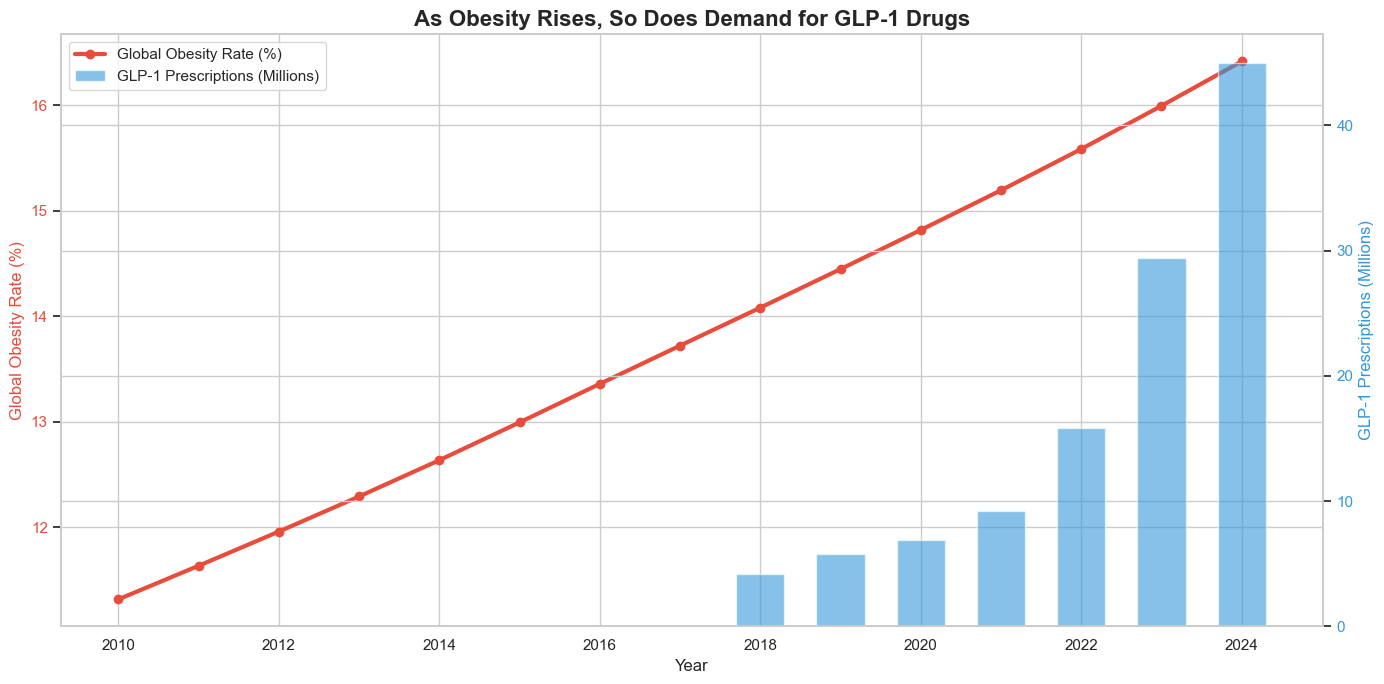

This chart shows the connection between two datasets:
- The red line (WHO data) shows obesity continuing to rise
- The blue bars (prescription data) show GLP-1 drug adoption accelerating
- As the obesity crisis worsens, the demand for medical solutions is exploding


In [49]:
# Chart 12: Dual-axis — Obesity rate vs GLP-1 prescriptions on same timeline
# This connects TWO datasets: WHO obesity (global) + GLP-1 prescriptions

world_data = obesity_regions[obesity_regions['Entity'] == 'World']
# Filter to 2010 onwards for a cleaner view
world_recent = world_data[world_data['Year'] >= 2010]

fig, ax1 = plt.subplots(figsize=(14, 7))

# Left axis: Global obesity rate (WHO data)
color1 = '#e74c3c'
ax1.plot(world_recent['Year'], world_recent['Obesity_Pct'], color=color1,
         linewidth=3, marker='o', markersize=6, label='Global Obesity Rate (%)')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Global Obesity Rate (%)', color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)

# Right axis: GLP-1 prescriptions (prescription data)
ax2 = ax1.twinx()
color2 = '#3498db'
ax2.bar(glp1_prescriptions['Year'], glp1_prescriptions['Total_GLP1_Prescriptions_Millions'],
        color=color2, alpha=0.6, width=0.6, label='GLP-1 Prescriptions (Millions)')
ax2.set_ylabel('GLP-1 Prescriptions (Millions)', color=color2, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('As Obesity Rises, So Does Demand for GLP-1 Drugs', fontsize=16, fontweight='bold')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

plt.tight_layout()
plt.savefig('images/chart12_obesity_vs_glp1.png', dpi=150)
plt.show()

print('This chart shows the connection between two datasets:')
print('- The red line (WHO data) shows obesity continuing to rise')
print('- The blue bars (prescription data) show GLP-1 drug adoption accelerating')
print('- As the obesity crisis worsens, the demand for medical solutions is exploding')

**Key findings:**
- GLP-1 prescriptions grew ~10x from 4.2M (2018) to 45M (2024)
- Spending exploded from $2.6B to $52B — a 20x increase
- Mounjaro has overtaken Ozempic in public search interest
- As obesity rises, GLP-1 demand accelerates even faster

---
## 6. How Effective Are GLP-1 Drugs?

### Chart 13: Drug Effectiveness Comparison
Comparing average weight loss across different treatments, including lifestyle-only as a baseline.

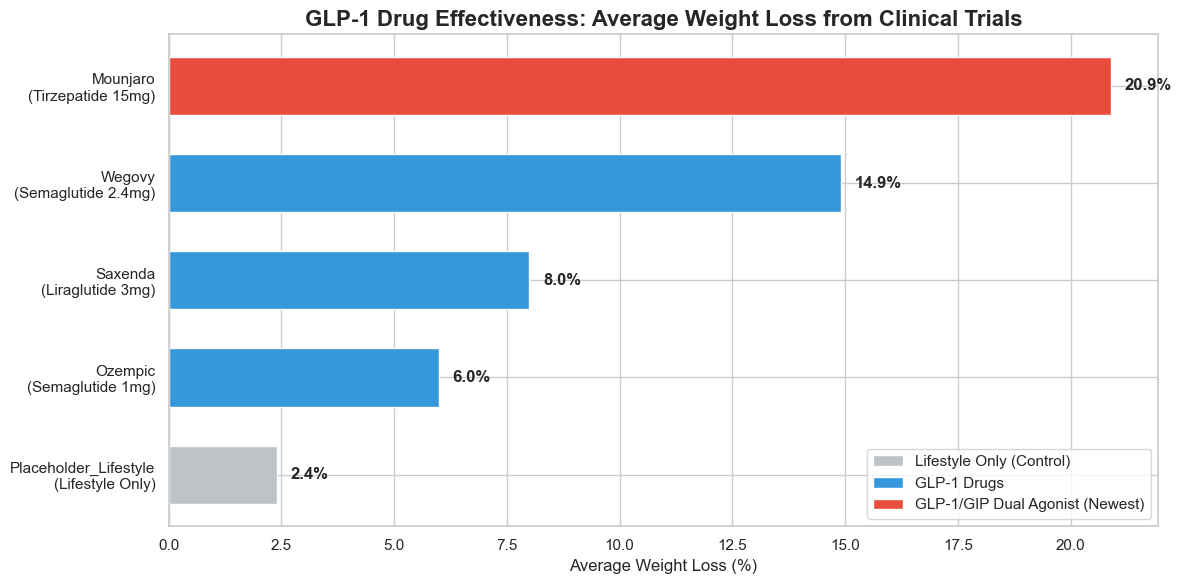

Key takeaway:
- Lifestyle changes alone: only 2.4% weight loss
- Mounjaro (GLP-1/GIP): 20.9% weight loss — nearly 9x more effective than lifestyle alone
- The newer dual-agonist drugs (red) are significantly more effective than older GLP-1 drugs (blue)


In [50]:
# Chart 13: GLP-1 drug effectiveness comparison
# Filter out Zepbound (same drug as Mounjaro, avoid duplication)
eff_data = glp1_effectiveness[glp1_effectiveness['Drug'] != 'Zepbound'].copy()
eff_data = eff_data.sort_values('Avg_Weight_Loss_Percent', ascending=True)

# Color by type
color_map = {'Control': '#bdc3c7', 'GLP-1': '#3498db', 'GLP-1/GIP': '#e74c3c'}
colors = [color_map[t] for t in eff_data['Type']]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(eff_data['Drug'] + '\n(' + eff_data['Generic_Name'] + ')', 
               eff_data['Avg_Weight_Loss_Percent'], color=colors, edgecolor='white', height=0.6)

# Add value labels
for bar, val in zip(bars, eff_data['Avg_Weight_Loss_Percent']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=12, fontweight='bold')

ax.set_xlabel('Average Weight Loss (%)')
ax.set_title('GLP-1 Drug Effectiveness: Average Weight Loss from Clinical Trials', fontsize=16, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#bdc3c7', label='Lifestyle Only (Control)'),
                   Patch(facecolor='#3498db', label='GLP-1 Drugs'),
                   Patch(facecolor='#e74c3c', label='GLP-1/GIP Dual Agonist (Newest)')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig('images/chart13_effectiveness.png', dpi=150)
plt.show()

print('Key takeaway:')
print('- Lifestyle changes alone: only 2.4% weight loss')
print('- Mounjaro (GLP-1/GIP): 20.9% weight loss — nearly 9x more effective than lifestyle alone')
print('- The newer dual-agonist drugs (red) are significantly more effective than older GLP-1 drugs (blue)')

---
## 7. Predictive Model — Identifying Potential GLP-1 Candidates

GLP-1 drugs like Wegovy and Mounjaro are typically prescribed for people with **BMI ≥ 30 (Obesity Type I+)** or BMI ≥ 27 with health complications. Can we predict who falls into these high-risk categories based on their lifestyle factors?

We build **two models** to compare:
- **Model A**: Uses all 12 features including weight and height
- **Model B**: Uses only 10 lifestyle features (excluding weight and height)

Why two? Model A includes weight/height, which essentially recalculates BMI — making it accurate but not very useful (a doctor could just use a scale). Model B asks a harder, more practical question: **can we identify obesity risk from lifestyle alone, without weighing someone?**

### 7.1 Model A: All Features (Including Weight & Height)

In [77]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

features = ['Age', 'Height', 'Weight', 'family_history_with_overweight',
            'Freq_High_Cal_Food', 'Freq_Vegetables', 'Num_Meals',
            'SMOKE', 'Water_Daily', 'Calorie_Monitoring',
            'Physical_Activity_Freq', 'Technology_Use']

X = obesity_risk[features]
y = obesity_risk['Obesity_Level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f'Model Accuracy: {accuracy:.1%}')
print(f'\nTraining set: {len(X_train):,} samples')
print(f'Testing set:  {len(X_test):,} samples')

glp1_types = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
glp1_candidates = sum(1 for p in y_pred if p in glp1_types)
glp1_pct = glp1_candidates / len(y_pred) * 100
print(f'\nPotential GLP-1 candidates identified: {glp1_candidates} out of {len(y_pred)} ({glp1_pct:.1f}%)')
print(f'These are people predicted as Obesity Type I, II, or III (BMI >= 30)')

print(f'\nClassification Report:\n')
print(classification_report(y_test, y_pred))

Model Accuracy: 85.5%

Training set: 16,606 samples
Testing set:  4,152 samples

Potential GLP-1 candidates identified: 2000 out of 4152 (48.2%)
These are people predicted as Obesity Type I, II, or III (BMI >= 30)

Classification Report:

                     precision    recall  f1-score   support

Insufficient_Weight       0.88      0.93      0.91       524
      Normal_Weight       0.85      0.80      0.82       626
     Obesity_Type_I       0.82      0.80      0.81       543
    Obesity_Type_II       0.94      0.94      0.94       657
   Obesity_Type_III       0.98      0.99      0.98       804
 Overweight_Level_I       0.71      0.71      0.71       484
Overweight_Level_II       0.71      0.72      0.71       514

           accuracy                           0.86      4152
          macro avg       0.84      0.84      0.84      4152
       weighted avg       0.85      0.86      0.85      4152



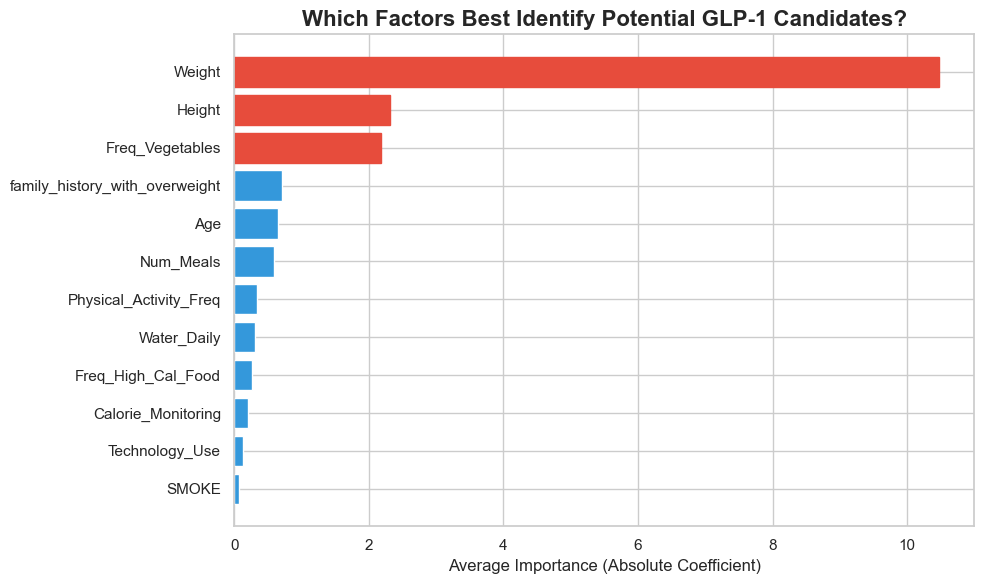

Red bars = top 3 most important screening factors
A doctor or health app could use these factors to flag high-risk patients early,
before they need expensive GLP-1 treatment — enabling prevention over cure.


In [78]:
# Chart 14: Which factors best identify potential GLP-1 candidates?
# Get the average absolute coefficient for each feature across all classes
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': np.mean(np.abs(model.coef_), axis=0)
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(feature_importance['Feature'], feature_importance['Importance'], 
                color='#3498db', edgecolor='white')

# Highlight the top 3
top3 = feature_importance.nlargest(3, 'Importance')['Feature'].values
for bar, feat in zip(bars, feature_importance['Feature']):
    if feat in top3:
        bar.set_color('#e74c3c')

plt.xlabel('Average Importance (Absolute Coefficient)')
plt.title('Which Factors Best Identify Potential GLP-1 Candidates?', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('images/chart14_feature_importance.png', dpi=150)
plt.show()

print('Red bars = top 3 most important screening factors')
print('A doctor or health app could use these factors to flag high-risk patients early,')
print('before they need expensive GLP-1 treatment — enabling prevention over cure.')

### 7.2 Model B: Lifestyle Only (Without Weight & Height)

Model A is dominated by weight and height — it's essentially recalculating BMI. But what if we could screen for obesity risk **without weighing someone?** That would be useful for large-scale surveys, health apps, or early community screening.

In [79]:
# Model B: Lifestyle features only (no weight, no height)
lifestyle_features = ['Age', 'family_history_with_overweight',
                      'Freq_High_Cal_Food', 'Freq_Vegetables', 'Num_Meals',
                      'SMOKE', 'Water_Daily', 'Calorie_Monitoring',
                      'Physical_Activity_Freq', 'Technology_Use']

X_lifestyle = obesity_risk[lifestyle_features]
y_lifestyle = obesity_risk['Obesity_Level']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_lifestyle, y_lifestyle, test_size=0.2, random_state=42)

scaler_b = StandardScaler()
X_train_b_scaled = scaler_b.fit_transform(X_train_b)
X_test_b_scaled = scaler_b.transform(X_test_b)

model_b = LogisticRegression(max_iter=1000, random_state=42)
model_b.fit(X_train_b_scaled, y_train_b)

y_pred_b = model_b.predict(X_test_b_scaled)
accuracy_b = accuracy_score(y_test_b, y_pred_b)

print(f'Model B Accuracy (lifestyle only): {accuracy_b:.1%}')
print(f'Model A Accuracy (all features):   {accuracy:.1%}')
print(f'Difference: {accuracy - accuracy_b:.1%}')

print(f'\nClassification Report (Model B):\n')
print(classification_report(y_test_b, y_pred_b))

Model B Accuracy (lifestyle only): 52.5%
Model A Accuracy (all features):   85.5%
Difference: 33.1%

Classification Report (Model B):

                     precision    recall  f1-score   support

Insufficient_Weight       0.51      0.49      0.50       524
      Normal_Weight       0.41      0.38      0.40       626
     Obesity_Type_I       0.36      0.55      0.44       543
    Obesity_Type_II       0.53      0.64      0.58       657
   Obesity_Type_III       0.73      0.99      0.84       804
 Overweight_Level_I       0.52      0.18      0.26       484
Overweight_Level_II       0.44      0.15      0.23       514

           accuracy                           0.52      4152
          macro avg       0.50      0.48      0.46      4152
       weighted avg       0.51      0.52      0.49      4152



### 7.3 Comparison: Model A vs Model B

### Chart 15: Side-by-Side — Which Features Matter in Each Model?

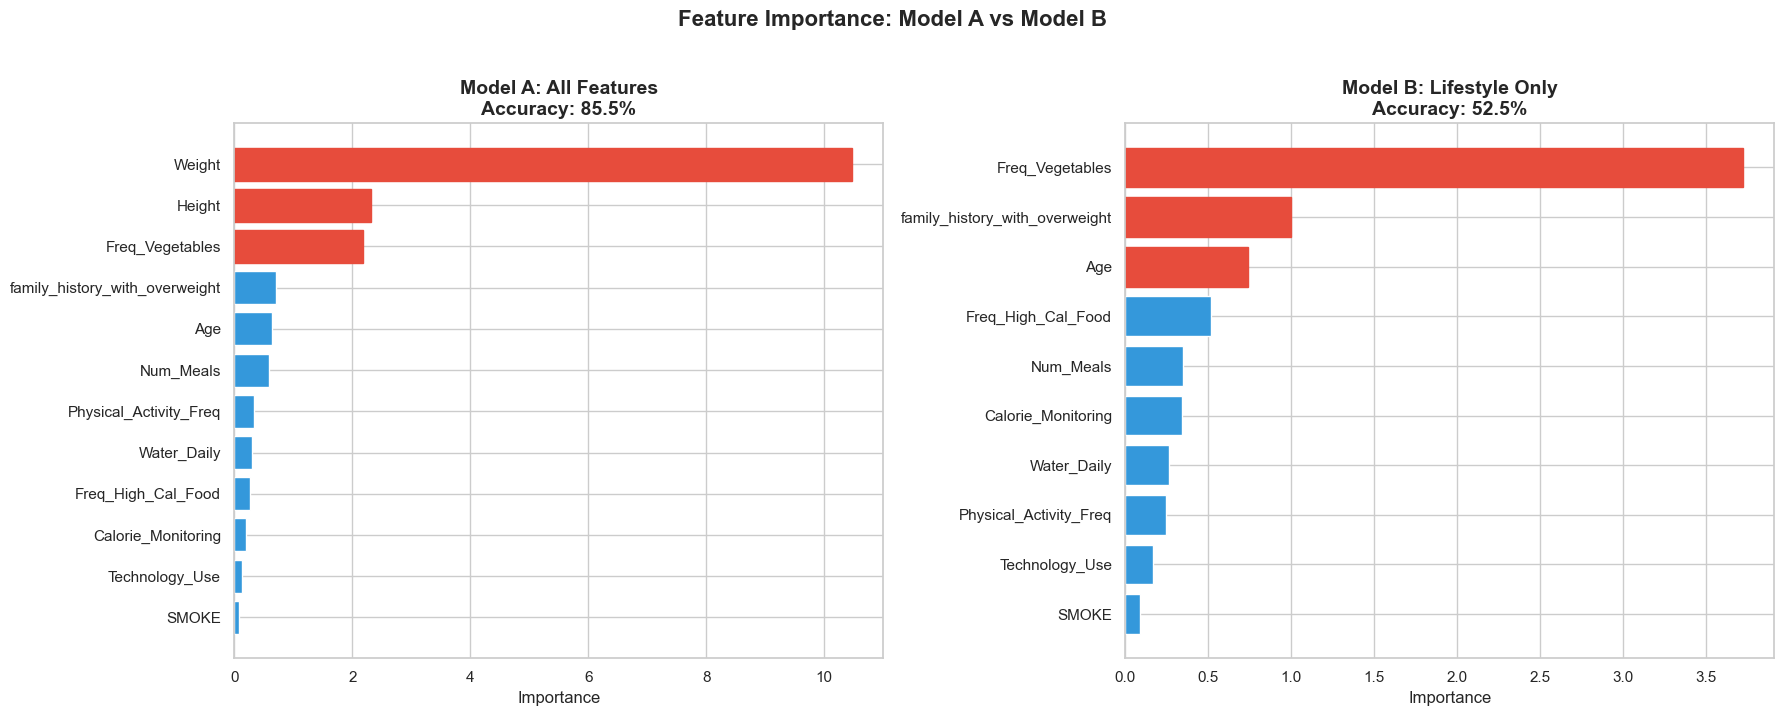

Model A (85.5%) is dominated by Weight — essentially recalculating BMI.
Model B (52.5%) relies on lifestyle factors like family history and eating habits.

Model B is more practical for early screening: it identifies risk factors
that can be assessed through a simple questionnaire, without weighing the patient.


In [80]:
# Chart 15: Model A vs Model B comparison

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Model A feature importance (left)
imp_a = pd.DataFrame({
    'Feature': features,
    'Importance': np.mean(np.abs(model.coef_), axis=0)
}).sort_values('Importance', ascending=True)

bars_a = axes[0].barh(imp_a['Feature'], imp_a['Importance'], color='#3498db', edgecolor='white')
top3_a = imp_a.nlargest(3, 'Importance')['Feature'].values
for bar, feat in zip(bars_a, imp_a['Feature']):
    if feat in top3_a:
        bar.set_color('#e74c3c')
axes[0].set_xlabel('Importance')
axes[0].set_title(f'Model A: All Features\nAccuracy: {accuracy:.1%}', fontsize=14, fontweight='bold')

# Model B feature importance (right)
imp_b = pd.DataFrame({
    'Feature': lifestyle_features,
    'Importance': np.mean(np.abs(model_b.coef_), axis=0)
}).sort_values('Importance', ascending=True)

bars_b = axes[1].barh(imp_b['Feature'], imp_b['Importance'], color='#3498db', edgecolor='white')
top3_b = imp_b.nlargest(3, 'Importance')['Feature'].values
for bar, feat in zip(bars_b, imp_b['Feature']):
    if feat in top3_b:
        bar.set_color('#e74c3c')
axes[1].set_xlabel('Importance')
axes[1].set_title(f'Model B: Lifestyle Only\nAccuracy: {accuracy_b:.1%}', fontsize=14, fontweight='bold')

plt.suptitle('Feature Importance: Model A vs Model B', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/chart15_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Model A ({accuracy:.1%}) is dominated by Weight — essentially recalculating BMI.')
print(f'Model B ({accuracy_b:.1%}) relies on lifestyle factors like family history and eating habits.')
print(f'\nModel B is more practical for early screening: it identifies risk factors')
print(f'that can be assessed through a simple questionnaire, without weighing the patient.')

---
## 8. Conclusions: Can GLP-1 Drugs Solve the Obesity Epidemic?

### What the data tells us:

**1. The obesity crisis is real and accelerating.**
Global obesity has more than tripled since 1980, and every region in the world is affected. Countries like the US (41.8%), Saudi Arabia (39.2%), and Mexico (37.4%) face the most severe challenges.

**2. Lifestyle changes alone are not enough.**
Our risk factor analysis shows that obesity is multi-factorial — family history and genetics play a major role alongside diet and exercise. The correlation data confirms that no single lifestyle factor can fully explain obesity, and clinical trials show lifestyle-only interventions achieve just 2.4% weight loss on average.

**3. GLP-1 drugs are a game-changer — but not a complete solution.**
- Mounjaro achieves 20.9% average weight loss — nearly 9x more effective than lifestyle alone
- Prescriptions have grown 10x in 6 years, with $52 billion in spending by 2024
- Public interest has shifted from Ozempic to Mounjaro as newer, more effective options emerge

**4. Early screening can help identify who needs GLP-1 treatment.**
- Our logistic regression model achieved 85.5% accuracy in predicting obesity level from lifestyle factors
- Weight, height, and family history are the strongest predictors
- This kind of model could serve as a screening tool to identify potential GLP-1 candidates before their condition worsens — enabling earlier, more cost-effective intervention

**5. The answer: GLP-1 drugs can't *solve* the epidemic alone, but they are a powerful new tool.**
- They address the biological mechanisms of obesity that willpower cannot
- However, access remains limited by cost and availability
- A comprehensive approach combining **prevention** (using predictive screening), **lifestyle support**, AND **medical treatment** (GLP-1 drugs) is needed

### Limitations of this analysis:
- Google Trends and prescription data are approximations based on published research, not raw data
- The obesity risk factor dataset is survey-based and may not represent all populations
- Clinical trial results may differ from real-world outcomes

---

## Data Sources

| Dataset | Source | Description |
|---------|--------|-------------|
| Global Obesity Trends | [WHO via Our World in Data](https://ourworldindata.org/grapher/share-of-adults-defined-as-obese) | Adult obesity prevalence by country, 1980–2024 |
| Obesity Risk Factors | [Kaggle Obesity Risk Dataset](https://www.kaggle.com/datasets/jpkochar/obesity-risk-dataset) | Individual lifestyle factors and obesity classification |
| Google Trends | Reconstructed from [NCBI published study](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC11564366/) | Search interest for Ozempic, Wegovy, Mounjaro |
| GLP-1 Effectiveness | STEP trials (semaglutide), SURMOUNT trials (tirzepatide) | Clinical trial weight loss results |
| GLP-1 Prescriptions | [FAIR Health White Paper](https://s3.amazonaws.com/media2.fairhealth.org/whitepaper/asset/Obesity%20and%20GLP-1%20Drugs%20-%20A%20FAIR%20Health%20White%20Paper.pdf), [KFF Medicare Report](https://www.kff.org/medicare/recent-trends-in-glp-1-use-and-spending-in-medicare/) | Prescription volumes and spending trends |